In [1]:
from google.colab import drive
# Mounting my Google Drive to access project files
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
# Setting my working directory to the project folder I just uploaded
project_path = '/content/drive/MyDrive/Homework1_Emad_Karimian_11018953'
os.chdir(project_path)

# Verifying that I am in the correct folder
print("Current folder:", os.getcwd())
# Listing files to make sure everything is there
print("Files in my project:", os.listdir())

Current folder: /content/drive/MyDrive/Homework1_Emad_Karimian_11018953
Files in my project: ['22_apps_flow_features.csv', 'Figures', 'Features']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import sklearn.metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
# All libraries are now imported and ready for the analysis!

In [4]:
# Task 1a) - Defining the create_dataset function
# I am building this function to filter specific traffic flows from the large dataset.
# It selects only the apps we need and the 20 specific features required by the lab.

def create_dataset(full_dataset_filename, app1, app2):
    # First, I load the complete dataset into a DataFrame
    print(f"I am reading the main dataset: {full_dataset_filename}")
    df = pd.read_csv(full_dataset_filename)

    # Selecting flows that belong to the two apps I want to distinguish
    # The 'ProtocolName' column holds the application labels
    selected_apps = df[(df['ProtocolName'] == app1) | (df['ProtocolName'] == app2)]

    # Now I must select the 20 specific features listed in the lab instructions
    # These include statistics for Forward, Backward, and Combined flows
    features_list = [
        'Fwd.Packet.Length.Mean', 'Fwd.Packet.Length.Max', 'Fwd.Packet.Length.Min',
        'Fwd.IAT.Mean', 'Fwd.IAT.Max', 'Fwd.IAT.Min',
        'Bwd.Packet.Length.Mean', 'Bwd.Packet.Length.Max', 'Bwd.Packet.Length.Min',
        'Bwd.IAT.Mean', 'Bwd.IAT.Max', 'Bwd.IAT.Min',
        'Packet.Length.Mean', 'Max.Packet.Length', 'Min.Packet.Length',
        'Flow.IAT.Mean', 'Flow.IAT.Max', 'Flow.IAT.Min',
        'Flow.Bytes.s', 'Flow.Packets.s',
        'ProtocolName' # Keeping this for labels
    ]

    selected_data = selected_apps[features_list]

    # Cleaning: Removing any flows with infinite, negative, or missing values
    # This ensures my machine learning models will have stable data to learn from
    selected_data = selected_data.replace([np.inf, -np.inf], np.nan).dropna()

    # Removing any duplicate entries to maintain a clean dataset
    selected_data = selected_data.drop_duplicates()

    # Defining the output filename and path inside the 'Features' folder
    output_filename = f"apps_flow_dataset_{app1}_{app2}.csv"
    output_path = os.path.join('Features', output_filename)

    # Saving the results to a CSV file
    selected_data.to_csv(output_path, index=False)
    print(f"My sub-dataset is created and saved at: {output_path}")

    return selected_data

# Task 1b) - Using the function for MS_ONE_DRIVE and YOUTUBE
# Now I call my function to generate the dataset for the first binary classification task.
dataset_1 = create_dataset('22_apps_flow_features.csv', 'MS_ONE_DRIVE', 'YOUTUBE')

I am reading the main dataset: 22_apps_flow_features.csv
My sub-dataset is created and saved at: Features/apps_flow_dataset_MS_ONE_DRIVE_YOUTUBE.csv


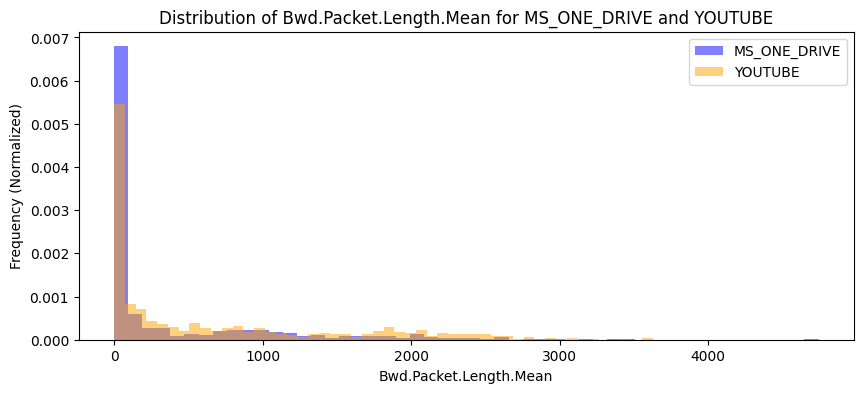

Plot for Bwd.Packet.Length.Mean is saved at: Figures/dist_Bwd.Packet.Length.Mean_MS_ONE_DRIVE_YOUTUBE.png


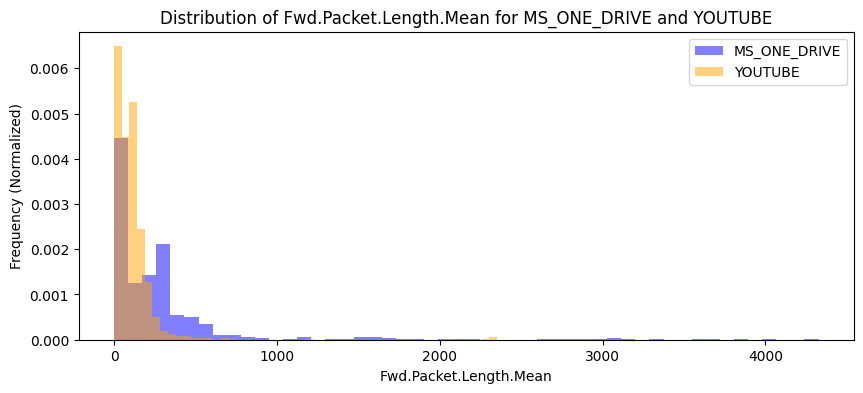

Plot for Fwd.Packet.Length.Mean is saved at: Figures/dist_Fwd.Packet.Length.Mean_MS_ONE_DRIVE_YOUTUBE.png


In [5]:
# Task 2a) - Defining the plot_feature_distribution function
# I am creating this function to visualize how features differ between apps.
# This visualization helps me understand if a feature is good for classification.

def plot_feature_distribution(data, app1, app2, feature_name):
    plt.figure(figsize=(10, 4))

    # Filtering data for each app to plot them separately
    data_app1 = data[data['ProtocolName'] == app1]
    data_app2 = data[data['ProtocolName'] == app2]

    # Plotting the histogram for the first app
    plt.hist(data_app1[feature_name], bins=50, alpha=0.5, label=app1, color='blue', density=True)

    # Plotting the histogram for the second app on the same graph
    plt.hist(data_app2[feature_name], bins=50, alpha=0.5, label=app2, color='orange', density=True)

    # Adding labels and titles to make the chart professional
    plt.title(f'Distribution of {feature_name} for {app1} and {app2}')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency (Normalized)')
    plt.legend()

    # Defining the save path inside the 'Figures' folder as instructed
    figure_name = f'dist_{feature_name}_{app1}_{app2}.png'
    save_path = os.path.join('Figures', figure_name)

    # Saving the plot and showing it in the notebook
    plt.savefig(save_path)
    plt.show()
    print(f"Plot for {feature_name} is saved at: {save_path}")

# Task 2b) - Visualizing specific features for MS_ONE_DRIVE and YOUTUBE
# Now I will check two important features: mean packet length in both directions.

# Plotting Backward Mean Packet Length
plot_feature_distribution(dataset_1, 'MS_ONE_DRIVE', 'YOUTUBE', 'Bwd.Packet.Length.Mean')

# Plotting Forward Mean Packet Length
plot_feature_distribution(dataset_1, 'MS_ONE_DRIVE', 'YOUTUBE', 'Fwd.Packet.Length.Mean')

In [ ]:
# Task 3a) - Defining the load_dataset function
# I am creating this function to convert our CSV data into numerical arrays (X and y).
# This is necessary because machine learning models only understand numbers.

def load_dataset(app1, app2):
    # Constructing the filename of the dataset I created in Task 1
    filename = f"Features/apps_flow_dataset_{app1}_{app2}.csv"
    df = pd.read_csv(filename)

    # Separating the features (X) from the labels (y)
    # I am removing the 'ProtocolName' column from X to keep only the 20 numerical features
    X = df.drop(columns=['ProtocolName']).values

    # Task 3a continued: Assigning binary labels
    # Following the instructions: MS_ONE_DRIVE = 0 and YOUTUBE = 1
    y = np.where(df['ProtocolName'] == app1, 0, 1)

    return X, y

# Task 3b) - Loading the dataset for MS_ONE_DRIVE and YOUTUBE
X, y = load_dataset('MS_ONE_DRIVE', 'YOUTUBE')

# Task 3c) - Doing a 80/20 split into train/test sets
# I'm using stratify=y to ensure that the proportion of apps is the same in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Checking the shapes and consistency as required by the lab manual
print("Full dataset shape (X, y):", X.shape, y.shape)
print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

# Checking the number of positives (YouTube = 1) in each set
print(f"Positives in full set: {np.sum(y)}")
print(f"Positives in training set: {np.sum(y_train)}")
print(f"Positives in testing set: {np.sum(y_test)}")

Full dataset shape (X, y): (1981, 20) (1981,)
Training set shape (X_train, y_train): (1584, 20) (1584,)
Testing set shape (X_test, y_test): (397, 20) (397,)
Positives in full set: 997
Positives in training set: 797
Positives in testing set: 200


In [7]:
# Task 4a) - Defining the train_classifier_logistic function
# I am building this function to find the best hyperparameters for Logistic Regression.
# I will use 5-fold cross-validation to ensure the model is robust and accurate.

def train_classifier_logistic(X_train, y_train):
    # Defining the range of regularization parameter 'C' and max iterations to test
    # A smaller C means more regularization (simpler model).
    c_list = [0.1, 1, 10, 100, 1000]
    max_iter_list = [1000, 5000, 10000]

    best_score = 0
    best_params = {}

    # Setting up the 5-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    print("Starting hyperparameter optimization for Logistic Regression...")
    start_time = time.time()

    # I will loop through all combinations to find which one performs best
    for c in c_list:
        for m_iter in max_iter_list:
            scores = []
            for train_idx, val_idx in kf.split(X_train):
                # Splitting training data into sub-train and validation sets
                X_t, X_v = X_train[train_idx], X_train[val_idx]
                y_t, y_v = y_train[train_idx], y_train[val_idx]

                # Initializing and training the model
                clf = LogisticRegression(C=c, max_iter=m_iter, solver='lbfgs')
                clf.fit(X_t, y_t)

                # Calculating accuracy on the validation fold
                score = clf.score(X_v, y_v)
                scores.append(score)

            # Calculating the mean score for this specific combination
            avg_score = np.mean(scores)
            if avg_score > best_score:
                best_score = avg_score
                best_params = {'regularization': c, 'max_iter': m_iter, 'score': avg_score}

    end_time = time.time()
    print(f"Optimization finished in {end_time - start_time:.2f} seconds.")
    print(f"Best hyperparameters found: {best_params}")

    # Now I train the final model on the full training set using the best parameters
    final_model = LogisticRegression(C=best_params['regularization'],
                                     max_iter=best_params['max_iter'])
    final_model.fit(X_train, y_train)

    return final_model, best_params

# Running the training function
# Note: This might take a couple of minutes to process
log_reg_model, best_cfg = train_classifier_logistic(X_train, y_train)

# Checking the final model score on the training set
print(f"Final training score: {log_reg_model.score(X_train, y_train)}")

Starting hyperparameter optimization for Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Optimization finished in 164.99 seconds.
Best hyperparameters found: {'regularization': 0.1, 'max_iter': 10000, 'score': np.float64(0.7190572215788842)}
Final training score: 0.7234848484848485


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
# Task 4b) - Standardizing the data
# I will use StandardScaler to bring all features to the same scale (mean=0, std=1).
# This is crucial for Logistic Regression to converge faster and more accurately.

scaler = StandardScaler()

# I must fit the scaler only on the training data to avoid data leakage,
# then use it to transform both the training and testing sets.
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("Data standardization is complete.")

# Task 4c) - Re-training the Logistic Regression on standardized data
# Now that the data is scaled, I expect the model to converge much faster
# and without those red warning messages.

print("Starting hyperparameter optimization on standardized data...")
start_time = time.time()

# I call the same training function we defined in Task 4a, but with standardized data
log_reg_model_std, best_cfg_std = train_classifier_logistic(X_train_std, y_train)

end_time = time.time()

print(f"Optimization finished in {end_time - start_time:.2f} seconds.")
print(f"Best hyperparameters after scaling: {best_cfg_std}")
print(f"Final training score (Standardized): {log_reg_model_std.score(X_train_std, y_train)}")

Data standardization is complete.
Starting hyperparameter optimization on standardized data...
Starting hyperparameter optimization for Logistic Regression...
Optimization finished in 4.45 seconds.
Best hyperparameters found: {'regularization': 1000, 'max_iter': 1000, 'score': np.float64(0.7317473944814918)}
Optimization finished in 4.49 seconds.
Best hyperparameters after scaling: {'regularization': 1000, 'max_iter': 1000, 'score': np.float64(0.7317473944814918)}
Final training score (Standardized): 0.726010101010101


In [9]:
# Task 4d) - Training the XGBoost classifier
# Now I am moving to a more sophisticated model: XGBoost.
# This algorithm is based on an ensemble of decision trees and usually
# provides much higher accuracy for network traffic classification.

def train_classifier_XGB(X_train, y_train):
    # I am defining the range of hyperparameters to test.
    # n_estimators is the number of trees, and max_depth is how complex each tree can be.
    n_estimators_list = [50, 100]
    max_depth_list = [3, 5]
    learning_rate_list = [0.01, 0.1]

    best_score = 0
    best_params = {}

    # Using 5-fold cross-validation again to be consistent and fair in my evaluation.
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    print("Starting hyperparameter optimization for XGBoost...")
    start_time = time.time()

    # I will iterate through all combinations to find the best configuration for my data.
    for n_est in n_estimators_list:
        for depth in max_depth_list:
            for lr in learning_rate_list:
                scores = []
                for train_idx, val_idx in kf.split(X_train):
                    X_t, X_v = X_train[train_idx], X_train[val_idx]
                    y_t, y_v = y_train[train_idx], y_train[val_idx]

                    # Initializing the XGBClassifier
                    # I use eval_metric='logloss' to ensure a clean output without warnings.
                    clf = XGBClassifier(n_estimators=n_est, max_depth=depth,
                                        learning_rate=lr, use_label_encoder=False,
                                        eval_metric='logloss', random_state=42)
                    clf.fit(X_t, y_t)

                    score = clf.score(X_v, y_v)
                    scores.append(score)

                avg_score = np.mean(scores)
                if avg_score > best_score:
                    best_score = avg_score
                    best_params = {'n_estimators': n_est, 'max_depth': depth,
                                   'learning_rate': lr, 'score': avg_score}

    end_time = time.time()
    print(f"XGBoost Optimization finished in {end_time - start_time:.2f} seconds.")
    print(f"Best XGBoost parameters found: {best_params}")

    # Finally, I train the model on the full training set with the best parameters found.
    final_model = XGBClassifier(n_estimators=best_params['n_estimators'],
                                 max_depth=best_params['max_depth'],
                                 learning_rate=best_params['learning_rate'],
                                 use_label_encoder=False, eval_metric='logloss',
                                 random_state=42)
    final_model.fit(X_train, y_train)

    return final_model, best_params

# Running the optimization on my standardized training data.
xgb_model, best_cfg_xgb = train_classifier_XGB(X_train_std, y_train)

# Checking the accuracy of my XGBoost model on the training set.
print(f"Final XGBoost training score: {xgb_model.score(X_train_std, y_train)}")

Starting hyperparameter optimization for XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Optimization finished in 7.93 seconds.
Best XGBoost parameters found: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'score': np.float64(0.9595915026155012)}
Final XGBoost training score: 0.9930555555555556


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Performance Analysis for: Logistic Regression ---
Accuracy:  0.7254
Precision: 0.6813
Recall:    0.8550
F1-score:  0.7583


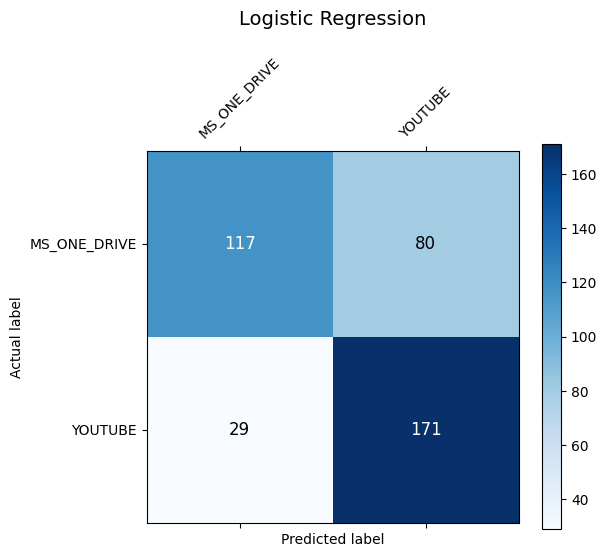

Confusion Matrix for Logistic Regression saved successfully.

--- Performance Analysis for: XGBoost ---
Accuracy:  0.9723
Precision: 0.9655
Recall:    0.9800
F1-score:  0.9727


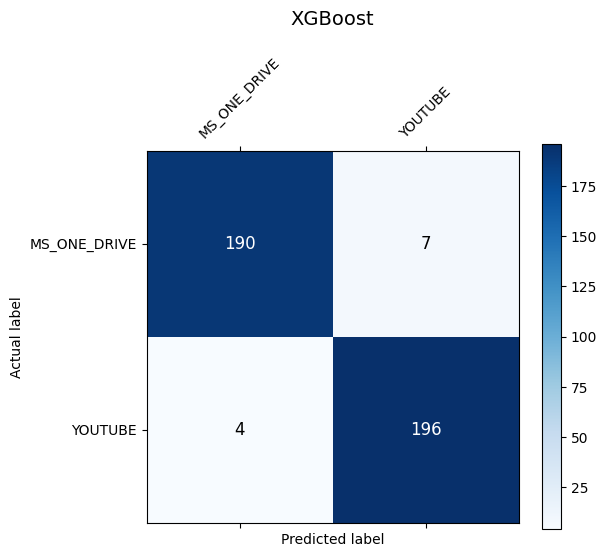

Confusion Matrix for XGBoost saved successfully.


In [12]:
# Task 5a) - Defining a more robust function to plot the Confusion Matrix
# I am using the object-oriented approach (fig, ax) to avoid figure management errors.
# This version is much more stable in Google Colab environments.
def plot_cm(y_true, y_pred, title, app1, app2):
    cm = confusion_matrix(y_true, y_pred)

    # Creating a figure and an axis object explicitly
    fig, ax = plt.subplots(figsize=(6, 5))

    # Displaying the matrix using matshow on the axis object
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    plt.title(title + '\n', fontsize=14)
    fig.colorbar(cax)

    # Setting the labels for clarity
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels([app1, app2], rotation=45)
    ax.set_yticklabels([app1, app2])

    # Adding numerical annotations in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), va='center', ha='center', fontsize=12,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

    ax.set_ylabel('Actual label')
    ax.set_xlabel('Predicted label')

    # Saving the final figure to my 'Figures' folder
    save_path = os.path.join('Figures', f'confusion_matrix_{title.replace(" ", "_")}.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Confusion Matrix for {title} saved successfully.")

# Task 5b & 5c) - Running the final evaluation for both models
# I am testing Logistic Regression and XGBoost on the unseen test set.
models_to_evaluate = {
    "Logistic Regression": (log_reg_model_std, X_test_std),
    "XGBoost": (xgb_model, X_test_std)
}

for name, (model, data) in models_to_evaluate.items():
    print(f"\n--- Performance Analysis for: {name} ---")

    # Getting predictions from the trained model
    y_pred = model.predict(data)

    # Displaying key classification metrics
    print(f"Accuracy:  {mt.accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {mt.precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {mt.recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {mt.f1_score(y_test, y_pred):.4f}")

    # Generating the visual confusion matrix
    plot_cm(y_test, y_pred, name, 'MS_ONE_DRIVE', 'YOUTUBE')

In [14]:
# Quick check to see the exact names of all 22 applications in the dataset
df_full = pd.read_csv('22_apps_flow_features.csv')
print("List of available applications in the dataset:")
print(df_full['ProtocolName'].unique())

List of available applications in the dataset:
['HTTP' 'GOOGLE' 'YOUTUBE' 'DROPBOX' 'WINDOWS_UPDATE' 'TOR' 'GMAIL'
 'SKYPE' 'MS_ONE_DRIVE' 'APPLE_ICLOUD' 'OFFICE_365' 'DNS' 'WHATSAPP'
 'FTP_DATA' 'MQTT' 'INSTAGRAM' 'GOOGLE_MAPS' 'NTP' 'TEAMVIEWER' 'SPOTIFY'
 'NETFLIX' 'SSH']



===== STARTING TASK 6: SKYPE vs DROPBOX =====
I am reading the main dataset: 22_apps_flow_features.csv
My sub-dataset is created and saved at: Features/apps_flow_dataset_SKYPE_DROPBOX.csv

Training Logistic Regression on Task 6 data...
Starting hyperparameter optimization for Logistic Regression...
Optimization finished in 7.90 seconds.
Best hyperparameters found: {'regularization': 1, 'max_iter': 1000, 'score': np.float64(0.8180489557960309)}

Training XGBoost on Task 6 data...
Starting hyperparameter optimization for XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Optimization finished in 6.82 seconds.
Best XGBoost parameters found: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'score': np.float64(0.9551391606436928)}

--- Final Metrics for Logistic Regression (SKYPE vs DROPBOX) ---
Accuracy:  0.8106
Precision: 0.9085
Recall:    0.6950
F1-score:  0.7875


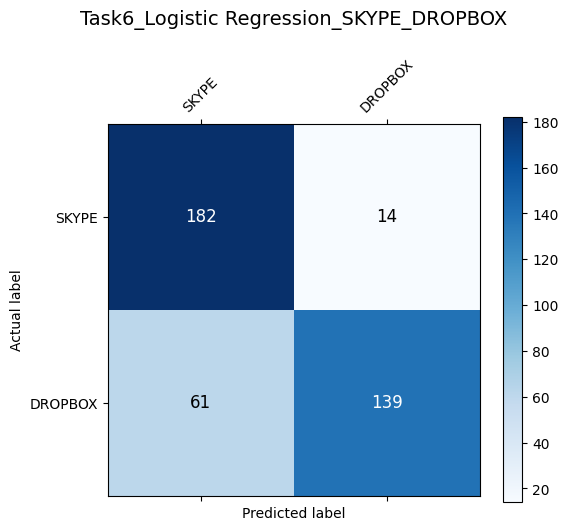

Confusion Matrix for Task6_Logistic Regression_SKYPE_DROPBOX saved successfully.

--- Final Metrics for XGBoost (SKYPE vs DROPBOX) ---
Accuracy:  0.9545
Precision: 0.9691
Recall:    0.9400
F1-score:  0.9543


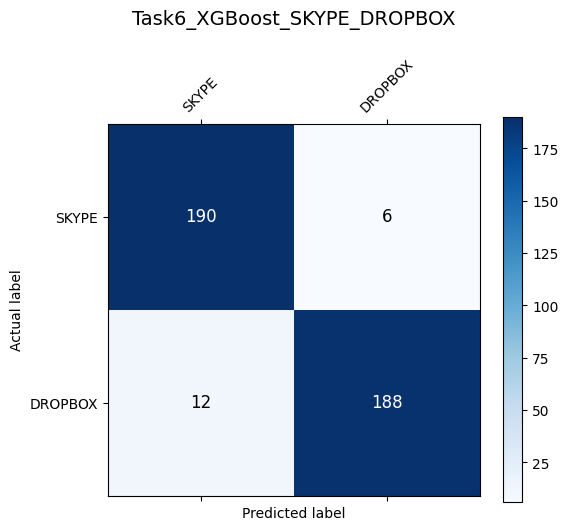

Confusion Matrix for Task6_XGBoost_SKYPE_DROPBOX saved successfully.


In [15]:
# Task 6: Comprehensive Generalization Workflow
# I am running the full pipeline for SKYPE and DROPBOX.
# This pair is perfect for testing how well the models distinguish between
# real-time communication and bulk file storage.

def run_task_6_workflow(app1, app2):
    print(f"\n===== STARTING TASK 6: {app1} vs {app2} =====")

    # 1. Dataset Creation (Task 1 for the new pair)
    create_dataset('22_apps_flow_features.csv', app1, app2)

    # 2. Loading and Labeling (Task 3 for the new pair)
    X_6, y_6 = load_dataset(app1, app2)

    # Ensuring we have both classes before proceeding
    if len(np.unique(y_6)) < 2:
        print(f"Error: Dataset for {app1} and {app2} is missing one class. Check the names!")
        return

    # 3. Data Splitting (80/20)
    X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(
        X_6, y_6, test_size=0.20, random_state=42, stratify=y_6
    )

    # 4. Standardization (Task 4b for the new pair)
    scaler_6 = StandardScaler()
    X_train_6_std = scaler_6.fit_transform(X_train_6)
    X_test_6_std = scaler_6.transform(X_test_6)

    # 5. Training and Evaluation Loop
    # I am reusing our optimized training logic for both models.
    results = {}

    # Training Logistic Regression
    print("\nTraining Logistic Regression on Task 6 data...")
    model_lr_6, _ = train_classifier_logistic(X_train_6_std, y_train_6)
    results["Logistic Regression"] = (model_lr_6, X_test_6_std)

    # Training XGBoost
    print("\nTraining XGBoost on Task 6 data...")
    model_xgb_6, _ = train_classifier_XGB(X_train_6_std, y_train_6)
    results["XGBoost"] = (model_xgb_6, X_test_6_std)

    # 6. Final Performance Analysis and Visualization
    for name, (model, data_test) in results.items():
        y_pred_6 = model.predict(data_test)
        print(f"\n--- Final Metrics for {name} ({app1} vs {app2}) ---")
        print(f"Accuracy:  {mt.accuracy_score(y_test_6, y_pred_6):.4f}")
        print(f"Precision: {mt.precision_score(y_test_6, y_pred_6):.4f}")
        print(f"Recall:    {mt.recall_score(y_test_6, y_pred_6):.4f}")
        print(f"F1-score:  {mt.f1_score(y_test_6, y_pred_6):.4f}")

        # Plotting the confusion matrix using our stable subplots method
        # I am adding 'Task6' to the title to distinguish these plots in the Figures folder
        plot_cm(y_test_6, y_pred_6, f"Task6_{name}_{app1}_{app2}", app1, app2)

# Now, running the final stage of my project with the best suggested pair:
run_task_6_workflow('SKYPE', 'DROPBOX')